In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/ML_2026/Praktikum_02/data/500_Person_Gender_Height_Weight_Index (1).csv')
df.head()

,Gender,Height,Weight,Index
0,Male,174,96,4
1,Male,189,87,2
2,Female,185,110,4
3,Female,195,104,3
4,Male,149,61,3


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Gender  500 non-null    object
 1   Height  500 non-null    int64 
 2   Weight  500 non-null    int64 
 3   Index   500 non-null    int64 
dtypes: int64(3), object(1)
memory usage: 15.8+ KB


In [ ]:
df['Height'].mean()

np.float64(169.944)

In [ ]:
df['Height'].median()

170.5

In [ ]:
df['Height'].mode()

,Height
0,188


In [ ]:
df.var(numeric_only=True)

,0
Height,268.149162
Weight,1048.633267
Index,1.836168


In [ ]:
df.std(numeric_only=True)

,0
Height,16.375261
Weight,32.382607
Index,1.355053


In [ ]:
# Hitung kuartil pertama (Q1)
q1 = df['Height'].quantile(0.25)
print("Q1 : ", q1)

# Hitung kuartil ketiga (Q3)
q3 = df['Height'].quantile(0.75)
print("Q3 : ", q3)

# Hitung IQR (Interquartile Range)
iqr = q3 - q1
print("IQR : ", iqr)


Q1 :  156.0
Q3 :  184.0
IQR :  28.0


<Axes: >

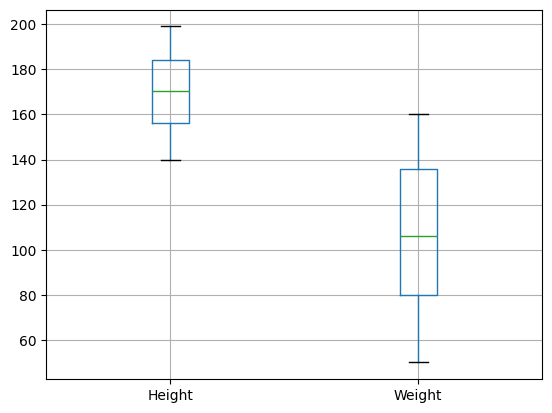

In [ ]:
import pandas as pd
import numpy as np

df.boxplot(['Height', 'Weight'])

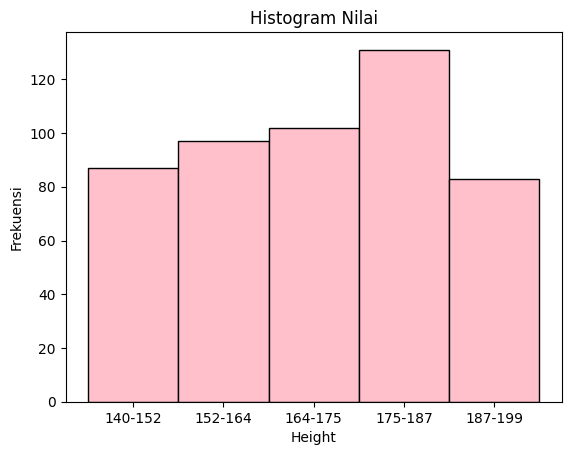

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Ambil data Height
data_height = df["Height"]

# Buat histogram
n, bins, patches = plt.hist(data_height, bins=5, color='pink', edgecolor='black')

# Tambahkan label
plt.title('Histogram Nilai')
plt.xlabel('Height')
plt.ylabel('Frekuensi')

# Tampilkan rentang frekuensi di sumbu x
bin_centers = 0.5 * (bins[:-1] + bins[1:])
plt.xticks(bin_centers, ['{:.0f}-{:.0f}'.format(bins[i], bins[i+1]) for i in range(len(bins)-1)])

# Tampilkan histogram
plt.show()


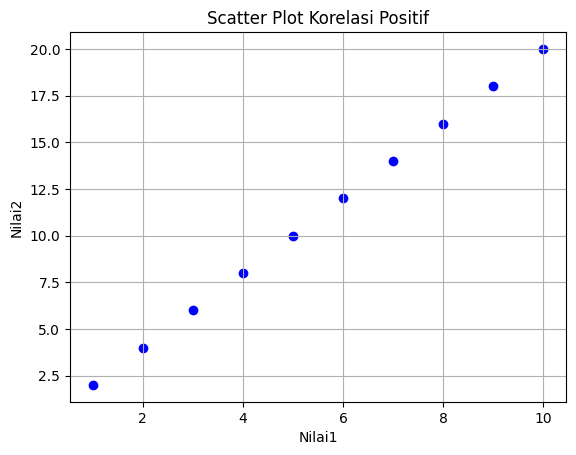

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Buat DataFrame contoh
data = {
    'Nilai1': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'Nilai2': [2, 4, 6, 8, 10, 12, 14, 16, 18, 20]
}

df2 = pd.DataFrame(data)

# Buat scatter plot
plt.scatter(df2['Nilai1'], df2['Nilai2'], color='blue', marker='o')

# Tambahkan label
plt.title('Scatter Plot Korelasi Positif')
plt.xlabel('Nilai1')
plt.ylabel('Nilai2')

# Tambahkan grid
plt.grid(True)

# Tampilkan plot
plt.show()


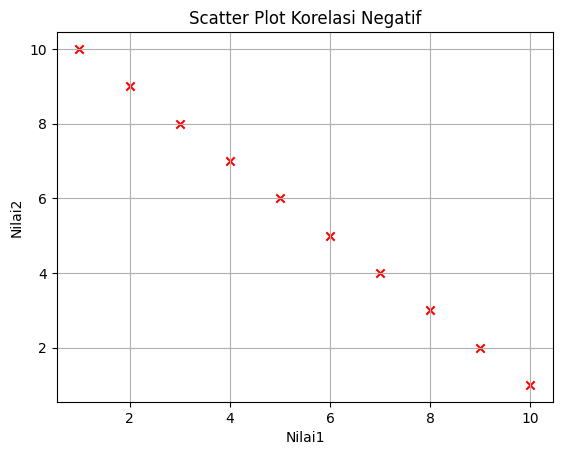

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Buat DataFrame contoh
data = {
    'Nilai1': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'Nilai2': [10, 9, 8, 7, 6, 5, 4, 3, 2, 1]
}

df3 = pd.DataFrame(data)

# Buat scatter plot
plt.scatter(df3['Nilai1'], df3['Nilai2'], color='red', marker='x')

# Tambahkan label
plt.title('Scatter Plot Korelasi Negatif')
plt.xlabel('Nilai1')
plt.ylabel('Nilai2')

# Tambahkan grid
plt.grid(True)

# Tampilkan plot
plt.show()


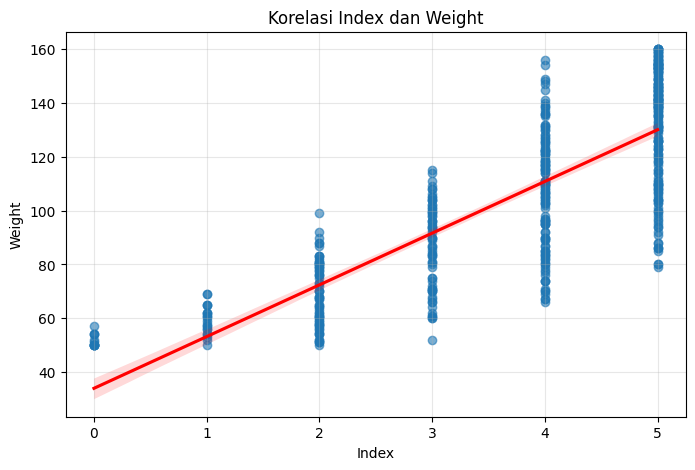

In [ ]:
# Scatter plot + garis regresi
plt.figure(figsize=(8, 5))

sns.regplot(
    data=df,
    x='Index',
    y='Weight',
    scatter_kws={'alpha': 0.6},
    line_kws={'color': 'red'}
)

plt.title('Korelasi Index dan Weight')
plt.xlabel('Index')
plt.ylabel('Weight')
plt.grid(True, alpha=0.3)

plt.show()


In [ ]:
# Menghitung matriks korelasi untuk semua kolom numerik
correlation_matrix = df[['Index', 'Weight']].corr(numeric_only=True)

# Menampilkan matriks korelasi
print("Matriks Korelasi:")
print(correlation_matrix)

Matriks Korelasi:
           Index    Weight
Index   1.000000  0.804569
Weight  0.804569  1.000000


In [ ]:
# Mengubah data bernilai string / object menjadi numerik
df_encoded = pd.get_dummies(
    df,
    columns=['Gender'],
    dtype=int
)
print("Data setelah One-Hot Encoding:")
display(df_encoded.head())

Data setelah One-Hot Encoding:


,Height,Weight,Index,Gender_Female,Gender_Male
0,174,96,4,0,1
1,189,87,2,0,1
2,185,110,4,1,0
3,195,104,3,1,0
4,149,61,3,0,1


In [ ]:
X = df_encoded.drop('Index', axis=1)
y = df_encoded['Index']

print("X:")
display(X.head())

print("y:")
display(y.head())

X:


,Height,Weight,Gender_Female,Gender_Male
0,174,96,0,1
1,189,87,0,1
2,185,110,1,0
3,195,104,1,0
4,149,61,0,1


y:


,Index
0,4
1,2
2,4
3,3
4,3


In [ ]:
from sklearn.model_selection import train_test_split

# Pisahkan data Testing (20%)
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)


# Pisahkan Training dan Validation Validation = 10% dari data training

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val,
    y_train_val,
    test_size=0.10,
    random_state=42
)

In [ ]:
# Output Pemisahan Data
print("Jumlah Data:")
print(f"Training   : {len(X_train)} data")
print(f"Validation : {len(X_val)} data")
print(f"Testing    : {len(X_test)} data")

print("\n5 Baris Data Training:")
display(X_train.head())

print("\n5 Baris Data Validation:")
display(X_val.head())

print("\n5 Baris Data Testing:")
display(X_test.head())

Jumlah Data:
Training   : 360 data
Validation : 40 data
Testing    : 100 data

5 Baris Data Training:


,Height,Weight,Gender_Female,Gender_Male
151,140,52,0,1
357,186,143,1,0
373,163,63,1,0
227,188,123,0,1
404,193,130,0,1



5 Baris Data Validation:


,Height,Weight,Gender_Female,Gender_Male
120,168,87,1,0
128,182,151,0,1
271,152,103,0,1
349,157,60,1,0
272,187,121,1,0



5 Baris Data Testing:


,Height,Weight,Gender_Female,Gender_Male
361,161,103,0,1
73,180,75,0,1
374,174,95,0,1
155,179,103,1,0
104,192,140,1,0


Praktikum Mandiri




In [7]:
import pandas as pd
df = pd.read_csv("/content/drive/MyDrive/ML_2026/praktikum_01/Data/day.csv")
df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [8]:
# 1. Memisahkan Fitur (X) dan Target (y)
# Sesuaikan 'cnt' dengan nama kolom target/label pada dataset Anda
X = df.drop(columns=['cnt'])
y = df['cnt']

# 2. Tahap 1: Memisahkan 20% Data Testing (Sisa 80% untuk Training + Validation)
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# 3. Tahap 2: Memisahkan Data Validation (10% dari data training/80% porsi awal)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val,
    y_train_val,
    test_size=0.10,
    random_state=42
)

# 4. Menampilkan Jumlah Data Masing-masing Bagian
print("=== Jumlah Data ===")
print(f"Total Data      : {len(df)} baris")
print(f"Data Training   : {len(X_train)} baris ({len(X_train)/len(df)*100:.1f}%)")
print(f"Data Validation : {len(X_val)} baris ({len(X_val)/len(df)*100:.1f}%)")
print(f"Data Testing    : {len(X_test)} baris ({len(X_test)/len(df)*100:.1f}%)")

# 5. Menampilkan Contoh Data
print("\n=== Contoh Data Training (5 Baris) ===")
display(X_train.head())

print("\n=== Contoh Data Validation (5 Baris) ===")
display(X_val.head())

print("\n=== Contoh Data Testing (5 Baris) ===")
display(X_test.head())

=== Jumlah Data ===
Total Data      : 731 baris
Data Training   : 525 baris (71.8%)
Data Validation : 59 baris (8.1%)
Data Testing    : 147 baris (20.1%)

=== Contoh Data Training (5 Baris) ===


,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered
657,658,2012-10-19,4,1,10,0,5,1,2,0.563333,0.537896,0.815000,0.134954,753,4671
163,164,2011-06-13,2,0,6,0,1,1,1,0.635000,0.601654,0.494583,0.305350,863,4157
305,306,2011-11-02,4,0,11,0,3,1,1,0.377500,0.390133,0.718750,0.082092,370,3816
111,112,2011-04-22,2,0,4,0,5,1,2,0.336667,0.321954,0.729583,0.219521,177,1506
538,539,2012-06-22,3,1,6,0,5,1,1,0.777500,0.724121,0.573750,0.182842,964,4859



=== Contoh Data Validation (5 Baris) ===


,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered
325,326,2011-11-22,4,0,11,0,2,1,3,0.416667,0.421696,0.962500,0.118792,69,1538
410,411,2012-02-15,1,1,2,0,3,1,1,0.348333,0.351629,0.531250,0.181600,141,4028
92,93,2011-04-03,2,0,4,0,0,0,1,0.378333,0.378767,0.480000,0.182213,1651,1598
47,48,2011-02-17,1,0,2,0,4,1,1,0.435833,0.428658,0.505000,0.230104,259,2216
508,509,2012-05-23,2,1,5,0,3,1,2,0.621667,0.584612,0.774583,0.102000,766,4494



=== Contoh Data Testing (5 Baris) ===


,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered
703,704,2012-12-04,4,1,12,0,2,1,1,0.475833,0.469054,0.733750,0.174129,551,6055
33,34,2011-02-03,1,0,2,0,4,1,1,0.186957,0.177878,0.437826,0.277752,61,1489
300,301,2011-10-28,4,0,10,0,5,1,2,0.330833,0.318812,0.585833,0.229479,456,3291
456,457,2012-04-01,2,1,4,0,0,0,2,0.425833,0.417287,0.676250,0.172267,2347,3694
633,634,2012-09-25,4,1,9,0,2,1,1,0.550000,0.544179,0.570000,0.236321,845,6693
